# BSL Gesture Recognition - Latency Benchmark (Colab)

This notebook measures end-to-end inference latency and throughput across models.

## Models under test
- Deep learning: 1D_CNN, Transformer_Encoder, ADANN
- Machine learning: LightGBM, XGBoost
- Hybrid: ADANN_LightGBM

## Methodology
1. Unified input shape and data type
2. Warmup runs (to stabilize caches/JIT)
3. N measurement runs and report mean latency and throughput
4. Export publication-ready plots (PNG 300 dpi and PDF)
5. Save raw results to CSV


# Section 1: Environment setup & libraries

In [1]:
!pip install torch torchvision torchaudio
!pip install tensorflow
!pip install lightgbm xgboost
!pip install pandas numpy matplotlib seaborn
!pip install psutil
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 24.3 MB/s eta 0:00:00


In [2]:
# Check GPU Environment
import torch
import tensorflow as tf

print(f"PyTorch CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name()}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

print(f"TensorFlow GPU: {tf.config.list_physical_devices('GPU')}")

# Set random seed
import numpy as np
np.random.seed(42)
torch.manual_seed(42)
tf.random.set_seed(42)

PyTorch CUDA available: True
GPU name: NVIDIA A100-SXM4-40GB
GPU memory: 39.6 GB
TensorFlow GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Section 2: Mount drive & load model files

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
project_root = "/content/drive/My Drive/Project"
os.chdir(project_root)

print(f"Working directory: {os.getcwd()}")

# List files for quick check
print("Current directory:", os.getcwd())
print("\nFiles:")
!ls -la

Mounted at /content/drive
Working directory: /content/drive/My Drive/Project
Current directory: /content/drive/My Drive/Project

Files:
total 22909
-rw------- 1 root root  15582 Aug  6 10:44 ADANN_LightGBM_算法详解.md
drwx------ 2 root root   4096 Aug  9 13:24 arduino
-rw------- 1 root root      0 Aug  8 16:11 BSL_延迟测试_Colab.ipynb
-rw------- 1 root root  24125 Aug  9 03:18 colab_latency_benchmark.py
-rw------- 1 root root  38767 Aug  9 04:05 Colab延迟测试代码.md
-rw------- 1 root root   5657 Aug  9 02:40 Colab延迟测试指南.md
-rw------- 1 root root   8146 Aug  6 10:44 compare_models.py
drwx------ 2 root root   4096 Aug  9 13:24 configs
drwx------ 2 root root   4096 Aug  9 13:24 datasets
-rw------- 1 root root  14340 Aug  8 17:42 .DS_Store
drwx------ 2 root root   4096 Aug  9 13:24 .git
-rw------- 1 root root    810 Jul 23 22:37 .gitignore
-rw------- 1 root root  33635 Aug 12 20:14 latency_benchmark_plot_arduino_loso_20250812_201428.pdf
-rw------- 1 root root 273024 Aug 12 20:14 latency_benchmark_plot_a

# Section 3: Quick model file check


In [4]:
# Quick model file check
model_dirs = [
    # standard
    "models/trained/1D_CNN/standard/full",
    "models/trained/Transformer_Encoder/standard/full",
    "models/trained/LightGBM/standard/full",
    "models/trained/XGBoost/standard/full",
    "models/trained/ADANN/standard/full",
    "models/trained/ADANN_LightGBM/standard/full",
    # loso
    "models/trained/1D_CNN/loso/full",
    "models/trained/Transformer_Encoder/loso/full",
    "models/trained/LightGBM/loso/full",
    "models/trained/XGBoost/loso/full",
    "models/trained/ADANN/loso/full",
    "models/trained/ADANN_LightGBM/loso/full"
]

for dir_path in model_dirs:
    if os.path.exists(dir_path):
        files = os.listdir(dir_path)
        print(f"{dir_path}: {len(files)} files")
    else:
        print(f"{dir_path}: missing")

models/trained/1D_CNN/standard/full: 4 files
models/trained/Transformer_Encoder/standard/full: 4 files
models/trained/LightGBM/standard/full: 3 files
models/trained/XGBoost/standard/full: 3 files
models/trained/ADANN/standard/full: 3 files
models/trained/ADANN_LightGBM/standard/full: 4 files
models/trained/1D_CNN/loso/full: 4 files
models/trained/Transformer_Encoder/loso/full: 4 files
models/trained/LightGBM/loso/full: 3 files
models/trained/XGBoost/loso/full: 3 files
models/trained/ADANN/loso/full: 3 files
models/trained/ADANN_LightGBM/loso/full: 4 files


# Section 4: Latency benchmark class

In [5]:
import time
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
import tensorflow as tf
import torch
import gc
import warnings
import os
import psutil
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

class ColabLatencyBenchmark:
    """Latency benchmark with two protocols:
    - 'gpu_full': original end-to-end style on A100 (keeps existing behavior)
    - 'cpu_arduino': Arduino-aligned inference-only on CPU; ML uses flattened window like Latency_Test.ipynb (sliced to n_features_in_)
    """

    @staticmethod
    def _first_existing_dir(candidates):
        for d in candidates:
            if os.path.exists(d):
                return d
        return candidates[0]

    def __init__(self, mode: str = 'gpu_full'):
        self.mode = mode
        self.results = []
        if self.mode == 'cpu_arduino':
            self.device = torch.device('cpu')
            self.num_warmup = 50
            self.num_runs = 1000
            self.batch_sizes = [1]
        else:
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            self.num_warmup = 50
            self.num_runs = 1000
            self.batch_sizes = [1, 4, 8, 16]

        # Sample inputs
        self.sample_data_dl = np.random.randn(1, 100, 5).astype(np.float32)
        self.sample_data_ml_flat = self.sample_data_dl.reshape(1, -1)

        # High-resolution timer and loop overhead estimation (ns)
        self._now = time.perf_counter_ns
        self._overhead_ns = self._estimate_timer_overhead_ns()

        print(f"Mode: {self.mode} | Device: {self.device}\nRuns: {self.num_runs}, Warmup: {self.num_warmup}")

    # ---------------------------------
    # Utils: timer overhead and Arduino-like features
    # ---------------------------------
    def _estimate_timer_overhead_ns(self, iters: int = 10000) -> int:
        # Measure minimal measurable overhead for empty timing section
        best = 1 << 60
        for _ in range(iters):
            t0 = self._now(); t1 = self._now()
            dt = t1 - t0
            if dt < best:
                best = dt
        return best

    @staticmethod
    def _ema_filter(window_100x5: np.ndarray, alpha: float = 0.1) -> np.ndarray:
        # window_100x5: shape (100, 5)
        out = np.empty_like(window_100x5, dtype=np.float32)
        out[0, :] = window_100x5[0, :]
        for ch in range(window_100x5.shape[1]):
            ema = float(window_100x5[0, ch])
            out[0, ch] = ema
            for t in range(1, window_100x5.shape[0]):
                ema = alpha * float(window_100x5[t, ch]) + (1.0 - alpha) * ema
                out[t, ch] = ema
        return out

    @staticmethod
    def _features_20_from_window(window_100x5: np.ndarray) -> np.ndarray:
        # 20-dim features: mean, std (population), min, max per channel (5 channels)
        feats = []
        for ch in range(window_100x5.shape[1]):
            x = window_100x5[:, ch].astype(np.float32)
            mean = float(np.mean(x))
            # population std to match Arduino implementation
            std = float(np.sqrt(max(0.0, float(np.mean(x * x) - mean * mean))))
            mn = float(np.min(x))
            mx = float(np.max(x))
            feats.extend([mean, std, mn, mx])
        return np.array(feats, dtype=np.float32).reshape(1, -1)

    # ---------------------------------
    # 1) Loaders
    # ---------------------------------
    def _load_tflite_model(self, model_path: str):
        try:
            interpreter = tf.lite.Interpreter(model_path=model_path)
            interpreter.allocate_tensors()
            return interpreter, 'tflite'
        except Exception as e:
            print(f"load TFLite fail: {e}"); return None, None

    def _load_ml_model(self, model_path: str, model_type: str):
        try:
            import pickle, sys
            if '.' not in sys.path:
                sys.path.insert(0, '.')
            with open(model_path, 'rb') as f:
                if model_type == 'LightGBM':
                    from src.training.train_lightgbm import LightgbmModelCreator  # ensure class is importable if needed
                data = pickle.load(f)
            model = data.get('lgb_model') or data.get('model', data) if isinstance(data, dict) else data
            return model, model_type.lower()
        except Exception as e:
            print(f"load {model_type} file: {e}"); return None, None

    def _load_pytorch_or_keras_package(self, model_path: str, model_type: str):
        # Try torch package first; fallback to Keras if .keras exists
        try:
            pkg = torch.load(model_path, map_location=self.device, weights_only=False)
            if isinstance(pkg, dict):
                for v in pkg.values():
                    if hasattr(v, 'eval'):
                        v.eval()
            elif hasattr(pkg, 'eval'):
                pkg.eval()
            return pkg, 'torch'
        except Exception:
            pass
        # Fallback: try Keras
        try:
            if model_path.endswith('.keras'):
                model = tf.keras.models.load_model(model_path)
                return model, 'keras'
        except Exception as e:
            print(f"load {model_type} as Keras fail: {e}")
        return None, None

    # ---------------------------------
    # 2) Inference kernels (inference-only when cpu_arduino)
    # ---------------------------------
    def _inference_once(self, model, framework: str, model_type: str, payload):
        # payload is framework-dependent, prebuilt when needed
        if framework == 'tflite':
            # payload: interpreter already has input tensor set for batch=1
            model.invoke()
            return
        if framework in ['lightgbm', 'xgboost']:
            x = payload  # shape (1, n)
            try:
                _ = model.predict_proba(x)
            except Exception:
                _ = model.predict(x)
            return
        if framework == 'torch':
            # Support dict payload for ADANN/Hybrid
            with torch.no_grad():
                if isinstance(payload, dict) and 'adann' in payload:
                    if 'x' in payload:
                        _ = payload['adann'](payload['x'])
                    else:
                        _ = payload['adann'](payload['x_adann'])
                else:
                    _ = model(payload)
            return
        if framework == 'keras':
            _ = model(payload, training=False) if callable(getattr(model, '__call__', None)) else model.predict(payload, verbose=0)
            return
        raise ValueError(f"Unknown framework: {framework}")

    # ---------------------------------
    # 3) Core Test Logic
    # ---------------------------------
    def benchmark_model(self, model_type, model_path, training_mode, batch_size):
        print(f"\n[Test] {model_type} ({training_mode}), batch_size={batch_size}")

        # Loader selection
        if model_type in ["1D_CNN", "Transformer_Encoder"]:
            model, framework = self._load_tflite_model(model_path)
            sample_data = self.sample_data_dl
        elif model_type in ["LightGBM", "XGBoost"]:
            model, framework = self._load_ml_model(model_path, model_type)
            sample_data = self.sample_data_ml_flat
        else:  # ADANN family
            model, framework = self._load_pytorch_or_keras_package(model_path, model_type)
            sample_data = self.sample_data_dl

        if model is None:
            print(f"[Skip] model load failed"); return None

        # Prepare inputs per protocol
        payload = None
        if self.mode == 'cpu_arduino':
            # Arduino-aligned: batch=1, inference-only timing
            if framework == 'tflite':
                # Pre-set input once; during timed loop, only invoke()
                input_details = model.get_input_details()[0]
                # Ensure shape (1, 100, 5) or compatible
                model.resize_tensor_input(input_details['index'], list(sample_data.shape), strict=False)
                model.allocate_tensors()
                model.set_tensor(input_details['index'], sample_data)
                payload = None  # not used
            elif framework in ['lightgbm', 'xgboost']:
                # 20-dim features after EMA
                window = sample_data.reshape(100, 5)
                ema = self._ema_filter(window)
                payload = self._features_20_from_window(ema)
            elif framework == 'torch':
                # ADANN family packaged as dict
                if model_type == 'ADANN' and isinstance(model, dict):
                    adann = model.get('adann_model') or model.get('model_object')
                    extractor = model.get('feature_extractor_obj', getattr(adann, 'feature_extractor_obj', None))
                    scaler = model.get('scaler', getattr(adann, 'scaler', None))
                    if adann is None or extractor is None or scaler is None:
                        print("[Skip] ADANN package missing components for Arduino mode"); return None
                    window = sample_data.reshape(100, 5)
                    feats = extractor.extract_comprehensive_features(window)
                    feats = np.asarray(feats, dtype=np.float32).reshape(1, -1)
                    feats = scaler.transform(feats).astype(np.float32)
                    x = torch.from_numpy(feats)
                    if hasattr(adann, 'to'): adann.to('cpu')
                    if hasattr(adann, 'eval'): adann.eval()
                    payload = {'adann': adann, 'x': x}
                elif model_type == 'ADANN_LightGBM' and isinstance(model, dict):
                    adann = model.get('adann_model')
                    lgbm = model.get('lightgbm_model')
                    adann_scaler = model.get('adann_scaler')
                    lgb_scaler = model.get('lgb_scaler')
                    extractor = model.get('hybrid_extractor')
                    if not all([adann, lgbm, adann_scaler, lgb_scaler, extractor]):
                        print("[Skip] ADANN_LightGBM package missing components for Arduino mode"); return None
                    window = sample_data.reshape(100, 5)
                    x_adann = extractor.enhanced_extractor.extract_comprehensive_features(window)
                    x_lgb = extractor.extract_lightgbm_features(window)
                    x_adann = adann_scaler.transform(np.asarray(x_adann, dtype=np.float32).reshape(1, -1)).astype(np.float32)
                    x_lgb = lgb_scaler.transform(np.asarray(x_lgb, dtype=np.float32).reshape(1, -1)).astype(np.float32)
                    x_adann_t = torch.from_numpy(x_adann)
                    if hasattr(adann, 'to'): adann.to('cpu')
                    if hasattr(adann, 'eval'): adann.eval()
                    payload = {'adann': adann, 'x_adann': x_adann_t, 'lgbm': lgbm, 'x_lgb': x_lgb}
                else:
                    # Generic torch/keras model: fall back to feeding raw sample (may not perfectly match Arduino head)
                    x = torch.from_numpy(sample_data.astype(np.float32))
                    payload = x.to('cpu')
                    if hasattr(model, 'to'): model.to('cpu')
                    if hasattr(model, 'eval'): model.eval()
            elif framework == 'keras':
                payload = sample_data
            else:
                print(f"[Skip] Unknown framework in Arduino mode: {framework}"); return None
        else:
            # Original full benchmark path (end-to-end timing including data movement)
            if framework == 'tflite':
                payload = np.repeat(sample_data, batch_size, axis=0)
            elif framework in ['lightgbm', 'xgboost']:
                payload = np.repeat(sample_data, batch_size, axis=0)
            else:
                payload = np.repeat(sample_data, batch_size, axis=0)

        # Warmup
        print(f"Warmup {framework}...")
        for _ in range(self.num_warmup):
            try:
                if self.mode == 'cpu_arduino':
                    self._inference_once(model, framework, model_type, payload)
                else:
                    # End-to-end path retains previous timing behavior
                    if framework == 'tflite':
                        input_details = model.get_input_details()[0]
                        output_details = model.get_output_details()[0]
                        expected_shape = list(input_details['shape'])
                        data = payload
                        if len(expected_shape) >= 1 and expected_shape[0] == 1 and data.shape[0] > 1:
                            for i in range(data.shape[0]):
                                model.set_tensor(input_details['index'], data[i:i+1])
                                model.invoke()
                                _ = model.get_tensor(output_details['index'])
                        else:
                            model.set_tensor(input_details['index'], data)
                            model.invoke()
                    elif framework in ['lightgbm', 'xgboost']:
                        data = payload
                        if hasattr(model, 'n_features_in_') and data.shape[1] != model.n_features_in_:
                            data = data[:, :model.n_features_in_]
                        try:
                            _ = model.predict_proba(data)
                        except Exception:
                            _ = model.predict(data)
                    else:
                        if framework == 'torch':
                            # Reuse original ADANN/Hybrid inference path for full benchmark
                            if model_type == 'ADANN':
                                if not isinstance(model, dict):
                                    raise ValueError('ADANN package expected dict in full mode')
                                adann = model.get('adann_model') or model.get('model_object')
                                extractor = model.get('feature_extractor_obj', getattr(adann, 'feature_extractor_obj', None))
                                scaler = model.get('scaler', getattr(adann, 'scaler', None))
                                if adann is None or extractor is None or scaler is None:
                                    raise ValueError('ADANN package missing components')
                                X_features = []
                                data = payload  # shape (B, 100, 5)
                                for sample in data:
                                    X_features.append(extractor.extract_comprehensive_features(sample))
                                X_features = np.array(X_features, dtype=np.float32)
                                X_scaled = scaler.transform(X_features)
                                input_tensor = torch.from_numpy(X_scaled).to(self.device)
                                if hasattr(adann, 'eval'): adann.eval()
                                with torch.no_grad():
                                    _ = adann(input_tensor)
                            elif model_type == 'ADANN_LightGBM':
                                if not isinstance(model, dict):
                                    raise ValueError('ADANN_LightGBM package expected dict in full mode')
                                adann = model['adann_model']; lgbm = model['lightgbm_model']
                                adann_scaler = model['adann_scaler']; lgb_scaler = model['lgb_scaler']
                                extractor = model['hybrid_extractor']
                                X_adann, X_lgb = [], []
                                data = payload
                                for sample in data:
                                    X_adann.append(extractor.enhanced_extractor.extract_comprehensive_features(sample))
                                    X_lgb.append(extractor.extract_lightgbm_features(sample))
                                X_adann = np.array(X_adann, dtype=np.float32)
                                X_lgb = np.array(X_lgb, dtype=np.float32)
                                X_adann_scaled = adann_scaler.transform(X_adann)
                                X_lgb_scaled = lgb_scaler.transform(X_lgb)
                                if hasattr(adann, 'eval'): adann.eval()
                                with torch.no_grad():
                                    _ = adann(torch.from_numpy(X_adann_scaled).to(self.device))
                                _ = lgbm.predict_proba(X_lgb_scaled)
                            else:
                                # Fallback: raw torch model
                                self._inference_once(model, 'torch', model_type, payload)
                        else:
                            self._inference_once(model, 'keras', model_type, payload)
            except Exception as e:
                print(f"[Skip] warmup failed: {e}"); return None

        # Measurement loop
        latencies_ms = []
        latencies_us = []
        for _ in range(self.num_runs):
            if self.mode == 'cpu_arduino':
                t0 = self._now()
                self._inference_once(model, framework, model_type, payload)
                t1 = self._now()
                dt_ns = max(0, (t1 - t0) - self._overhead_ns)
                lat_us = dt_ns / 1000.0
                latencies_us.append(lat_us)
            else:
                t0 = time.time()
                # reuse same logic as warmup for full path
                if framework == 'tflite':
                    input_details = model.get_input_details()[0]
                    output_details = model.get_output_details()[0]
                    expected_shape = list(input_details['shape'])
                    data = payload
                    if len(expected_shape) >= 1 and data.shape[0] > 1 and expected_shape[0] == 1:
                        for i in range(data.shape[0]):
                            model.set_tensor(input_details['index'], data[i:i+1])
                            model.invoke()
                            _ = model.get_tensor(output_details['index'])
                    else:
                        model.set_tensor(input_details['index'], data)
                        model.invoke()
                elif framework in ['lightgbm', 'xgboost']:
                    data = payload
                    if hasattr(model, 'n_features_in_') and data.shape[1] != model.n_features_in_:
                        data = data[:, :model.n_features_in_]
                    try:
                        _ = model.predict_proba(data)
                    except Exception:
                        _ = model.predict(data)
                else:
                    if framework == 'torch':
                        # Reuse original ADANN/Hybrid inference path for full benchmark (batch-aware)
                        if model_type == 'ADANN':
                            if not isinstance(model, dict):
                                raise ValueError('ADANN package expected dict in full mode')
                            adann = model.get('adann_model') or model.get('model_object')
                            extractor = model.get('feature_extractor_obj', getattr(adann, 'feature_extractor_obj', None))
                            scaler = model.get('scaler', getattr(adann, 'scaler', None))
                            if adann is None or extractor is None or scaler is None:
                                raise ValueError('ADANN package missing components')
                            X_features = []
                            data = payload  # shape (B, 100, 5)
                            for sample in data:
                                X_features.append(extractor.extract_comprehensive_features(sample))
                            X_features = np.array(X_features, dtype=np.float32)
                            X_scaled = scaler.transform(X_features)
                            input_tensor = torch.from_numpy(X_scaled).to(self.device)
                            if hasattr(adann, 'eval'): adann.eval()
                            with torch.no_grad():
                                _ = adann(input_tensor)
                        elif model_type == 'ADANN_LightGBM':
                            if not isinstance(model, dict):
                                raise ValueError('ADANN_LightGBM package expected dict in full mode')
                            adann = model['adann_model']; lgbm = model['lightgbm_model']
                            adann_scaler = model['adann_scaler']; lgb_scaler = model['lgb_scaler']
                            extractor = model['hybrid_extractor']
                            X_adann, X_lgb = [], []
                            data = payload
                            for sample in data:
                                X_adann.append(extractor.enhanced_extractor.extract_comprehensive_features(sample))
                                X_lgb.append(extractor.extract_lightgbm_features(sample))
                            X_adann = np.array(X_adann, dtype=np.float32)
                            X_lgb = np.array(X_lgb, dtype=np.float32)
                            X_adann_scaled = adann_scaler.transform(X_adann)
                            X_lgb_scaled = lgb_scaler.transform(X_lgb)
                            if hasattr(adann, 'eval'): adann.eval()
                            with torch.no_grad():
                                _ = adann(torch.from_numpy(X_adann_scaled).to(self.device))
                            _ = lgbm.predict_proba(X_lgb_scaled)
                        else:
                            self._inference_once(model, 'torch', model_type, payload)
                    else:
                        self._inference_once(model, 'keras', model_type, payload)
                latencies_ms.append((time.time() - t0) * 1000.0)

        # Summarize
        if self.mode == 'cpu_arduino':
            if not latencies_us:
                print(f"[Skip] all inference failed"); return None
            mean_us = float(np.mean(latencies_us))
            std_us = float(np.std(latencies_us))
            ips = 1e6 / mean_us if mean_us > 0 else 0.0
            result = {
                'model_name': model_type,
                'training_mode': training_mode,
                'batch_size': 1,
                'mean_latency_us': mean_us,
                'std_latency_us': std_us,
                'throughput_inf_per_sec': ips,
            }
            print(f"✅ Mean Inference Latency: {mean_us:.2f}µs | Throughput: {ips:.2f} inf/sec")
        else:
            if not latencies_ms:
                print(f"[Skip] all inference failed"); return None
            mean_ms = float(np.mean(latencies_ms))
            std_ms = float(np.std(latencies_ms))
            ips = (1000.0 * batch_size) / mean_ms if mean_ms > 0 else 0.0
            result = {
                'model_name': model_type,
                'training_mode': training_mode,
                'batch_size': batch_size,
                'mean_latency_ms': mean_ms,
                'std_latency_ms': std_ms,
                'throughput_inf_per_sec': ips,
            }
            print(f"✅ Mean Inference Latency: {mean_ms:.3f}ms | Throughput: {ips:.2f} inf/sec")

        # Cleanup
        del model, payload
        gc.collect()
        if self.device.type == 'cuda':
            torch.cuda.empty_cache()
        return result

    # ---------------------------------
    # 4) Model discovery and orchestration
    # ---------------------------------
    def find_latest_model(self, model_dir, model_type):
        if not os.path.exists(model_dir):
            return None, None
        if model_type in ["1D_CNN", "Transformer_Encoder"]:
            exts = [".tflite"]
        elif model_type in ["LightGBM", "XGBoost"]:
            exts = [".pkl"]
        else:
            exts = [".pth", ".pt", ".pth.tar", ".keras"]
        files = []
        for f in os.listdir(model_dir):
            if f.startswith('scaler_'):
                continue
            for ext in exts:
                if f.endswith(ext):
                    files.append(f)
                    break
        files = sorted(files, reverse=True)
        if not files:
            print(f" The dir exists but has not found {model_type} recognizable model file: {model_dir}")
            print(f"   Include files: {sorted(os.listdir(model_dir))[:10]}")
            return None, None
        return os.path.join(model_dir, files[0]), files[0]

    def _model_matrix(self):
        if self.mode == 'cpu_arduino':
            # Arduino-aligned on CPU: allow Transformer as user wants to test it
            return [
                ("1D_CNN", self._first_existing_dir(["models/trained/1D_CNN/standard/arduino", "models/trained/1D_CNN/standard/full"]), "standard"),
                ("1D_CNN", self._first_existing_dir(["models/trained/1D_CNN/loso/arduino", "models/trained/1D_CNN/loso/full"]), "loso"),
                ("Transformer_Encoder", "models/trained/Transformer_Encoder/standard/full", "standard"),
                ("Transformer_Encoder", "models/trained/Transformer_Encoder/loso/full", "loso"),
                ("LightGBM", "models/trained/LightGBM/standard/full", "standard"),  # Python model with flattened 500 features sliced to n_features_in_
                ("LightGBM", "models/trained/LightGBM/loso/full", "loso"),
                ("XGBoost", "models/trained/XGBoost/standard/full", "standard"),
                ("XGBoost", "models/trained/XGBoost/loso/full", "loso"),
                ("ADANN", self._first_existing_dir(["models/trained/ADANN/standard/arduino", "models/trained/ADANN/standard/full"]), "standard"),
                ("ADANN", self._first_existing_dir(["models/trained/ADANN/loso/arduino", "models/trained/ADANN/loso/full"]), "loso"),
                ("ADANN_LightGBM", self._first_existing_dir(["models/trained/ADANN_LightGBM/standard/arduino", "models/trained/ADANN_LightGBM/standard/full"]), "standard"),
                ("ADANN_LightGBM", self._first_existing_dir(["models/trained/ADANN_LightGBM/loso/arduino", "models/trained/ADANN_LightGBM/loso/full"]), "loso"),
            ]
        else:
            return [
                ("1D_CNN", "models/trained/1D_CNN/standard/full", "standard"),
                ("1D_CNN", "models/trained/1D_CNN/loso/full", "loso"),
                ("Transformer_Encoder", "models/trained/Transformer_Encoder/standard/full", "standard"),
                ("Transformer_Encoder", "models/trained/Transformer_Encoder/loso/full", "loso"),
                ("LightGBM", "models/trained/LightGBM/standard/full", "standard"),
                ("LightGBM", "models/trained/LightGBM/loso/full", "loso"),
                ("XGBoost", "models/trained/XGBoost/standard/full", "standard"),
                ("XGBoost", "models/trained/XGBoost/loso/full", "loso"),
                ("ADANN", "models/trained/ADANN/standard/full", "standard"),
                ("ADANN", "models/trained/ADANN/loso/full", "loso"),
                ("ADANN_LightGBM", "models/trained/ADANN_LightGBM/standard/full", "standard"),
                ("ADANN_LightGBM", "models/trained/ADANN_LightGBM/loso/full", "loso"),
            ]

    def run_benchmark(self):
        print("Starting BSL inference latency benchmark...")
        print("=" * 60)
        for model_type, model_dir, training_mode in self._model_matrix():
            model_path, model_name = self.find_latest_model(model_dir, model_type)
            if not model_path:
                print(f"[Skip] {model_type} ({training_mode}) model file not found in {model_dir}")
                continue
            # Skip Transformer in Arduino-mode explicitly (just in case)
            if self.mode == 'cpu_arduino' and model_type == 'Transformer_Encoder':
                print("[Skip] Transformer_Encoder is not supported on Arduino")
                continue
            print(f"\n[Model] {model_name} ({training_mode})")
            for batch_size in self.batch_sizes:
                result = self.benchmark_model(model_type, model_path, training_mode, batch_size)
                if result is not None:
                    self.results.append(result)
        self.save_and_visualize_results()

    def save_and_visualize_results(self):
        if not self.results:
            print(" There are no test results to save.")
            return
        df = pd.DataFrame(self.results)
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        suffix = 'arduino' if self.mode == 'cpu_arduino' else 'full'
        csv_path = f"latency_benchmark_results_{suffix}_{timestamp}.csv"
        df.to_csv(csv_path, index=False)
        print(f"\nSaved results to: {csv_path}")
        self.print_summary(df)
        self.generate_academic_plots(df, timestamp)

    def print_summary(self, df: pd.DataFrame):
        print("\n" + "=" * 60)
        if self.mode == 'cpu_arduino':
            print("Latency results summary (mean latency in µs)")
            print("=" * 60)
            if 'mean_latency_us' in df.columns:
                pivot = df.pivot_table(index=['model_name', 'training_mode'], columns='batch_size', values='mean_latency_us')
                print(pivot.to_string(float_format="%.2f"))
        else:
            print("Latency results summary (mean latency in ms)")
            print("=" * 60)
            pivot = df.pivot_table(index=['model_name', 'training_mode'], columns='batch_size', values='mean_latency_ms')
            print(pivot.to_string(float_format="%.3f"))

    def generate_academic_plots(self, df: pd.DataFrame, timestamp: str):
        print("\nGenerating plots...")
        plt.style.use('seaborn-v0_8-whitegrid')
        for mode in ['standard', 'loso']:
            mode_df = df[df['training_mode'] == mode].copy()
            if mode_df.empty:
                continue
            fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=150)
            title_suffix = 'Arduino-aligned' if self.mode == 'cpu_arduino' else 'Full'
            fig.suptitle(f'Inference Performance Benchmark ({mode.capitalize()} Training) - {title_suffix}', fontsize=16, fontweight='bold')

            if self.mode == 'cpu_arduino':
                ax1 = sns.barplot(data=mode_df, x='model_name', y='mean_latency_us', hue='batch_size', ax=axes[0], palette='viridis')
                ax1.set_title('Mean Inference Latency (µs)', fontsize=12)
                ax1.set_ylabel('Mean Latency (µs)')
            else:
                ax1 = sns.barplot(data=mode_df, x='model_name', y='mean_latency_ms', hue='batch_size', ax=axes[0], palette='viridis')
                ax1.set_title('Mean Inference Latency (ms)', fontsize=12)
                ax1.set_ylabel('Mean Latency (ms)')
            ax1.set_xlabel('')
            ax1.set_yscale('log')
            ax1.tick_params(axis='x', rotation=30, labelsize=10)
            for p in ax1.patches:
                ax1.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                             ha='center', va='center', fontsize=8, color='black', xytext=(0, 5), textcoords='offset points')
            ax1.legend(title='Batch Size', loc='upper left')

            ax2 = sns.lineplot(data=mode_df, x='batch_size', y='throughput_inf_per_sec', hue='model_name', marker='o', ax=axes[1], palette='tab10')
            ax2.set_title('Throughput vs. Batch Size', fontsize=12)
            ax2.set_ylabel('Throughput (inferences/sec)')
            ax2.set_xlabel('Batch Size')
            ax2.set_xticks(self.batch_sizes)
            ax2.legend(title='Model', loc='upper left')
            ax2.set_yscale('log')
            ax2.grid(True, which="both", ls="--")

            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            suffix = 'arduino' if self.mode == 'cpu_arduino' else 'full'
            plot_path_png = f"latency_benchmark_plot_{mode}_{suffix}_{timestamp}.png"
            plot_path_pdf = f"latency_benchmark_plot_{mode}_{suffix}_{timestamp}.pdf"
            plt.savefig(plot_path_png, dpi=300)
            plt.savefig(plot_path_pdf)
            print(f"Saved plots: {plot_path_png}, {plot_path_pdf}")
            plt.show()

# Section 5: Run the benchmark

Mode: gpu_full | Device: cuda
Runs: 1000, Warmup: 50
Starting BSL inference latency benchmark...

[Model] 1D_CNN_standard_20250812_054459.tflite (standard)

[Test] 1D_CNN (standard), batch_size=1
Warmup tflite...
✅ Mean Inference Latency: 0.051ms | Throughput: 19683.44 inf/sec

[Test] 1D_CNN (standard), batch_size=4
Warmup tflite...
✅ Mean Inference Latency: 0.160ms | Throughput: 25024.97 inf/sec

[Test] 1D_CNN (standard), batch_size=8
Warmup tflite...
✅ Mean Inference Latency: 0.303ms | Throughput: 26366.92 inf/sec

[Test] 1D_CNN (standard), batch_size=16
Warmup tflite...
✅ Mean Inference Latency: 0.579ms | Throughput: 27630.72 inf/sec

[Model] 1D_CNN_loso_final_20250812_060420.tflite (loso)

[Test] 1D_CNN (loso), batch_size=1
Warmup tflite...
✅ Mean Inference Latency: 0.047ms | Throughput: 21456.98 inf/sec

[Test] 1D_CNN (loso), batch_size=4
Warmup tflite...
✅ Mean Inference Latency: 0.144ms | Throughput: 27761.68 inf/sec

[Test] 1D_CNN (loso), batch_size=8
Warmup tflite...
✅ Mean In

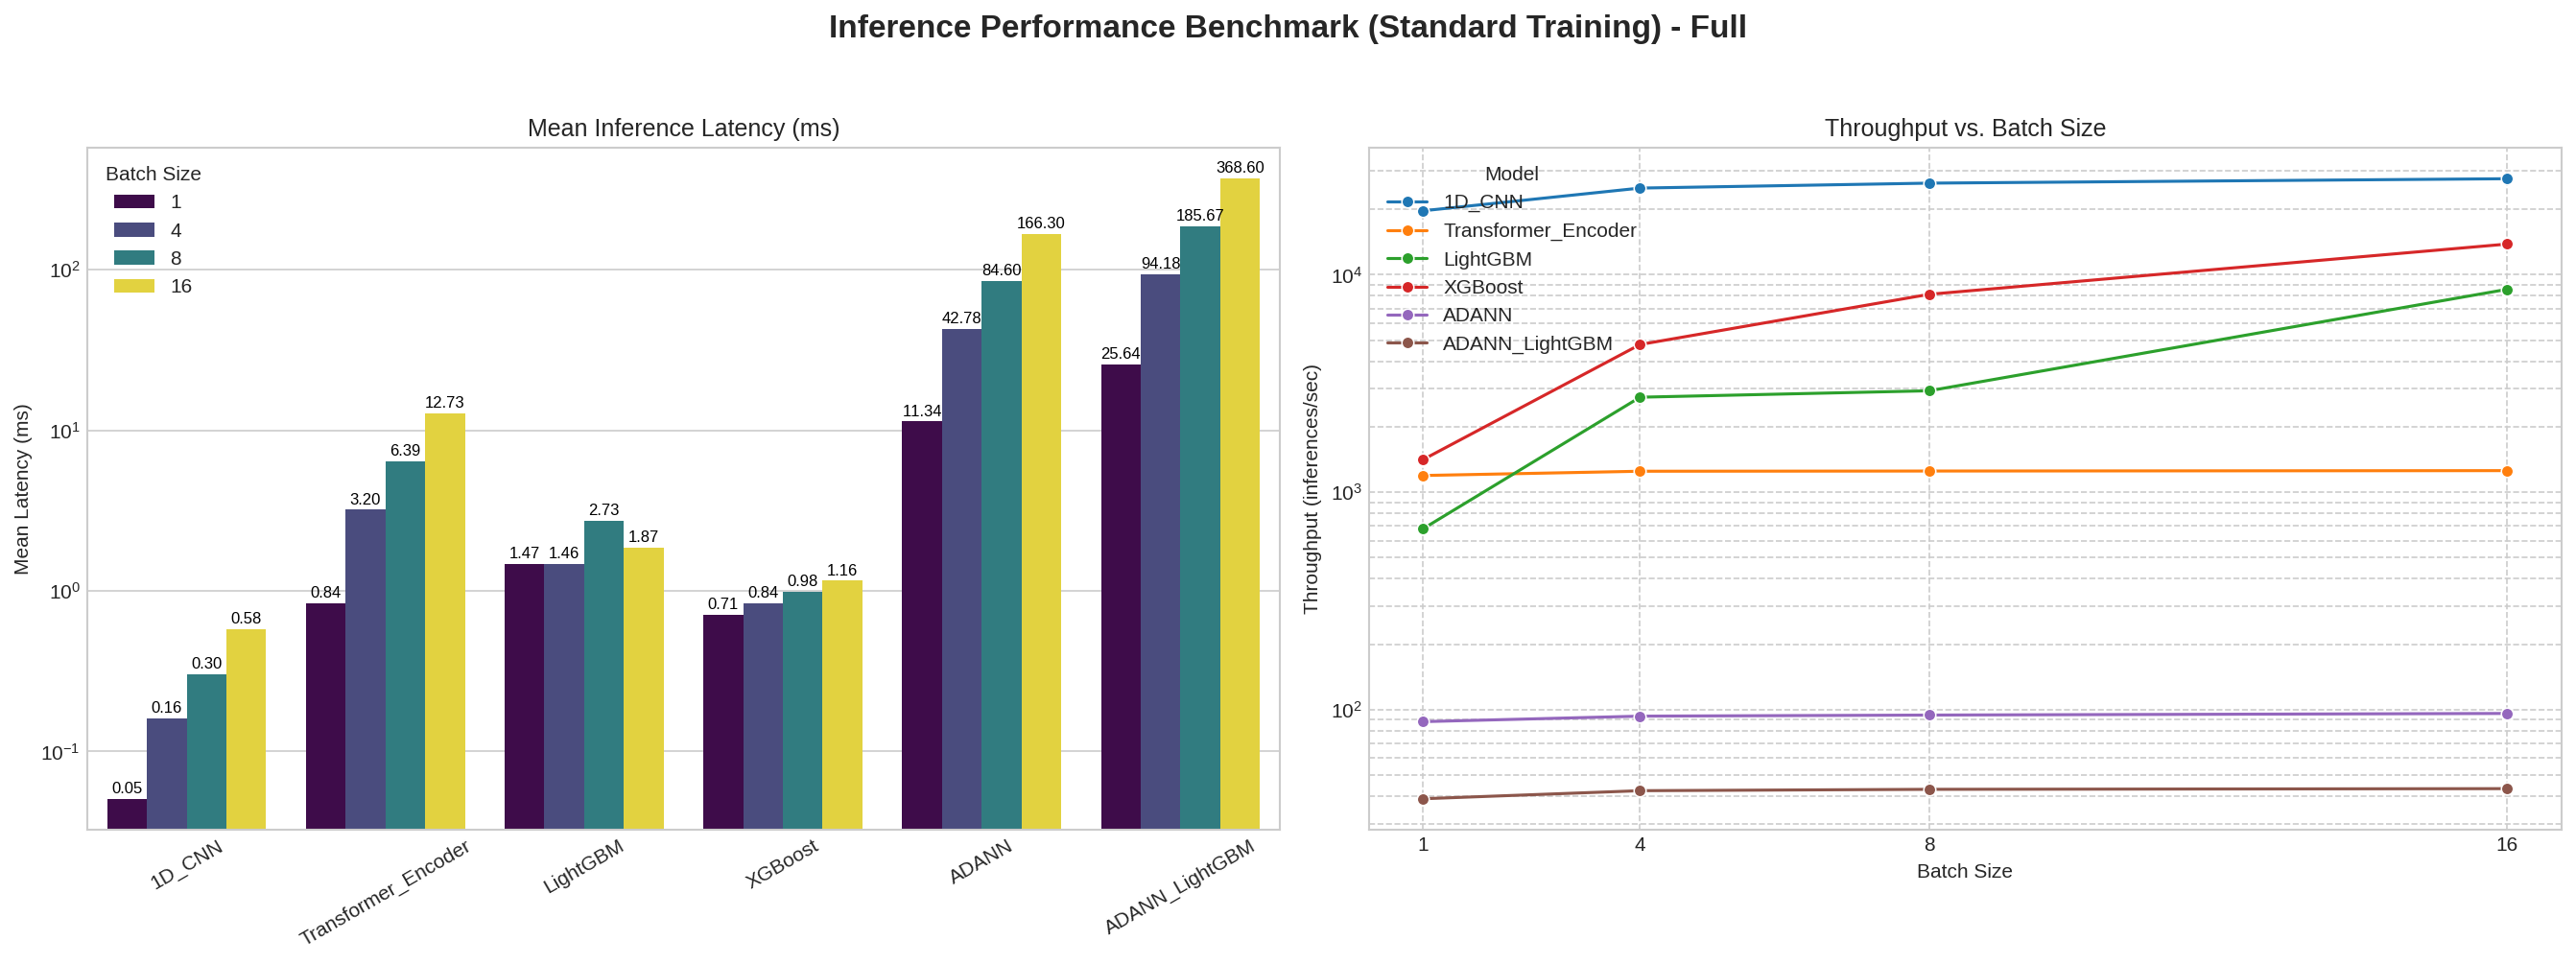

Saved plots: latency_benchmark_plot_loso_full_20250813_001659.png, latency_benchmark_plot_loso_full_20250813_001659.pdf


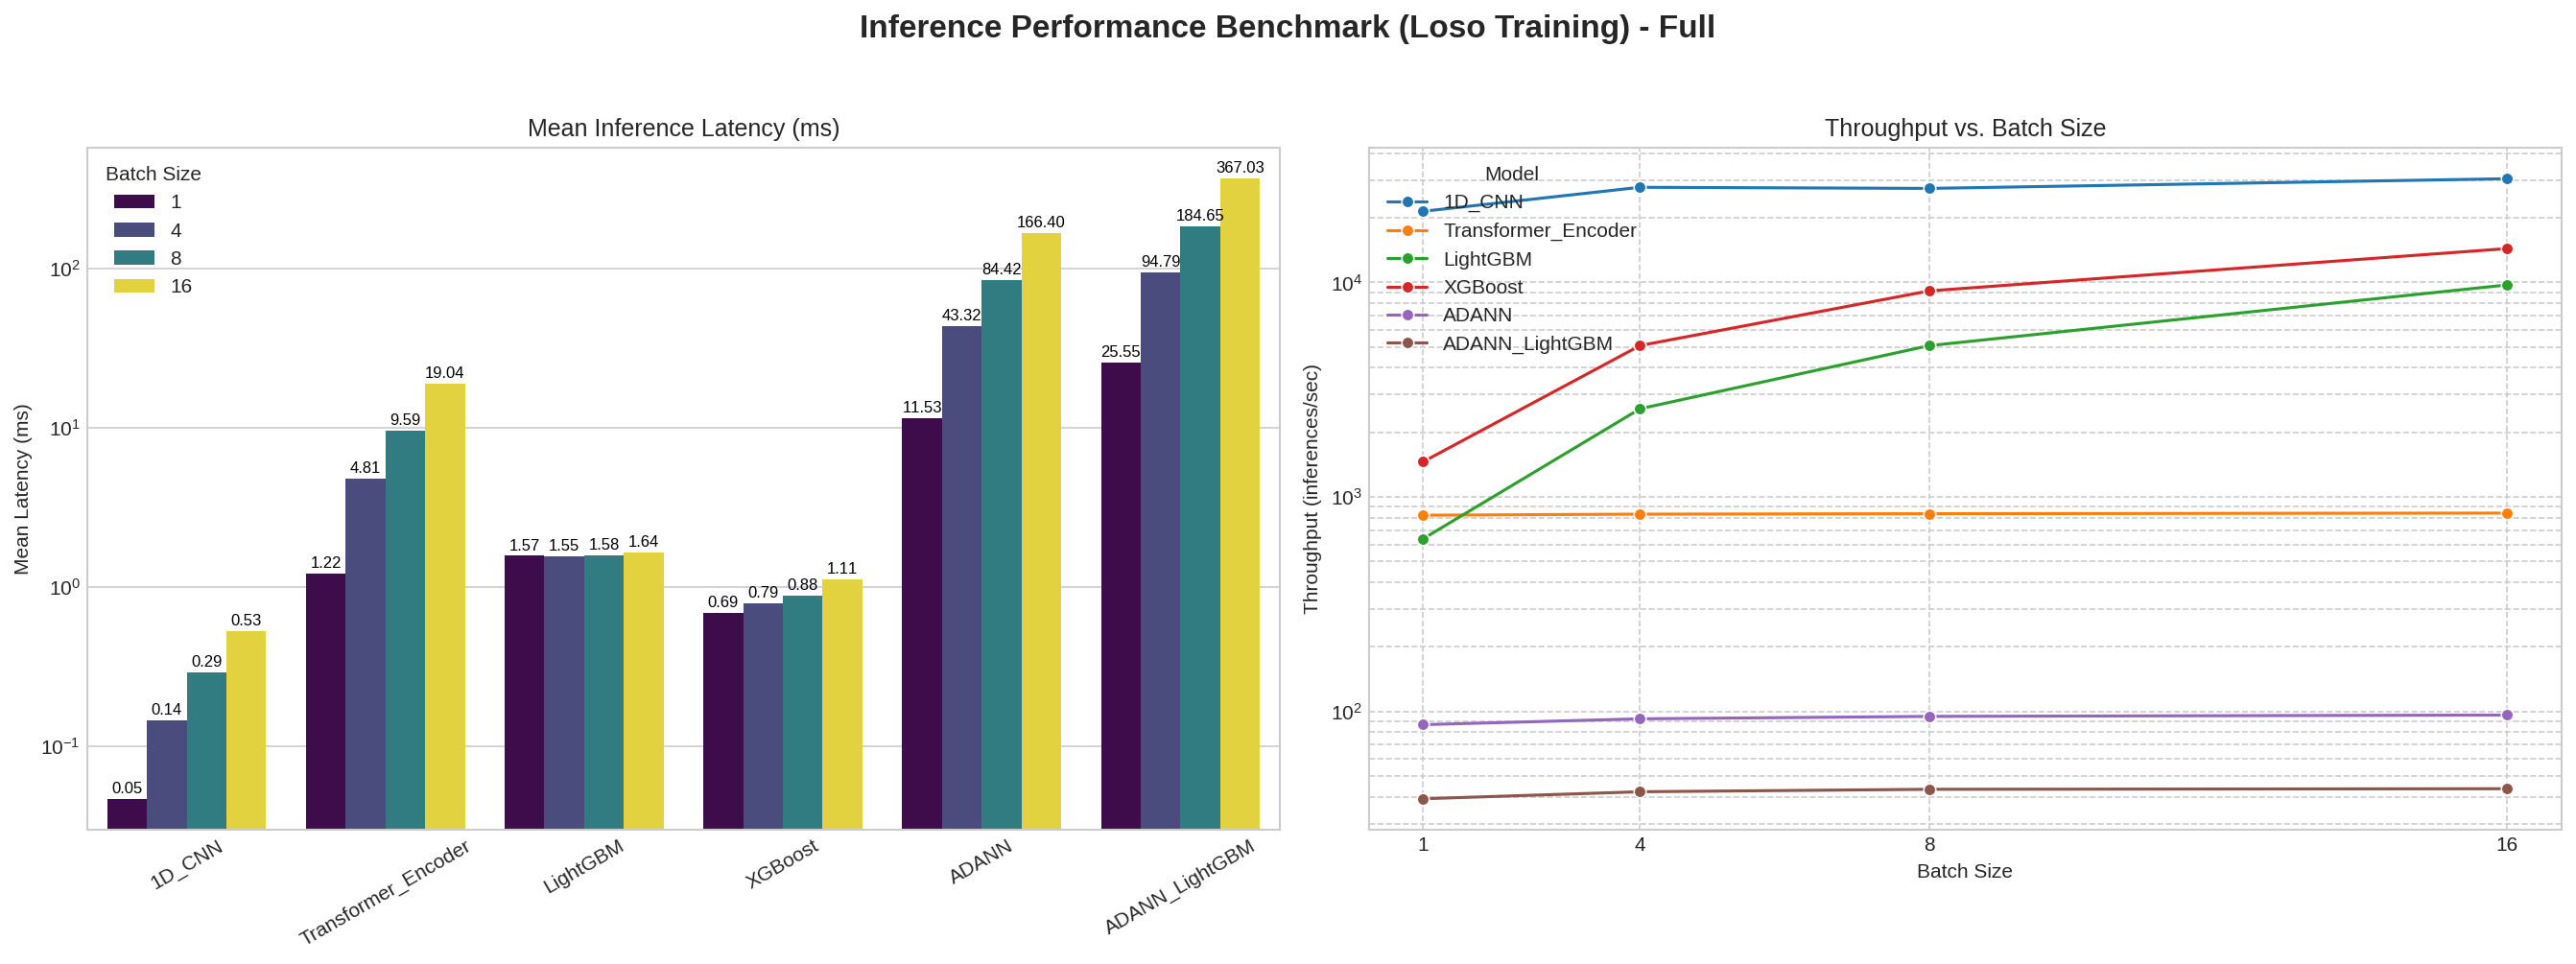

In [6]:
# Run full (A100/GPU) end-to-end benchmark
benchmark = ColabLatencyBenchmark(mode='gpu_full')
benchmark.run_benchmark()